Todo: do a full end to end reconstruction of EIT with Tikhonov regularization and save the image. Then change the noise level

In [24]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics

Just choose the parameters here: 
The current problem is the scale might vary widely based on the chosen grid. Don't know yet how to normalize it.

In [25]:
ρ_obj = 1e-7 
ρ_reg = 5e-2 # Regularization strength in prox of regularizer

σf = 1.0e-2 # how much noise is added to f
σg = 1.0e-2 # How much noise is added to g

0.01

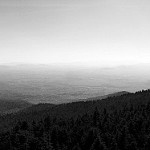

In [26]:
img = load("1096.jpg")

In [27]:
itp = interpolate_array_2D(Float64.(img))

#interpolate_array_2D##0 (generic function with 1 method)

In [28]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)

16129-element Vector{Float64}:
 0.6620719480307282
 0.6844350473112841
 0.6927977157805241
 0.670285221753101
 0.675713612074557
 0.6894434399964393
 0.6841917536040899
 0.6672001101490131
 0.6806489158672027
 0.6971524452344506
 ⋮
 0.031167250350174543
 0.015510000235997821
 0.014520427059962142
 0.007829287198868317
 0.008838059259167145
 0.008600073232173749
 0.014341377282337257
 0.012685658965159607
 0.01946419980123187

In [29]:
minimum(cond_vec)

1.0e-6

In [30]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [31]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  3.497424 seconds (915.99 k allocations: 901.545 MiB, 43.85% gc time, 16.47% compilation time)


In [32]:
Statistics.std(mode_dict[1].g)

1.8993588489722277

In [33]:
#σ_vec = randn(fe.n) #initialize problem with random vector
#@. σ_vec = min(max(σ_vec*0.5 +0.5, 1e-6),1.0)
using Distributions
σ_vec = rand(Uniform(1e-6, 1.0), fe.n)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_dict, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [34]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [35]:
R, ∇R, prox_reg = create_tikhonov(fe.K,β = 1.0,ρ = ρ_reg)

(ModularEIT.var"#85#86"{Float64, SparseArrays.SparseMatrixCSC{Float64, Int64}}(1.0, sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129], [0.6222222222222229, -0.03333333333333323, -0.022222222222222247, -0.03333333333333331, -0.2000000000000008, 0.11111111111111119, 0.11111111111111122, -0.19999999999999993, -0.3555555555555557, -0.03333333333333323  …  -1.066666666666667, -0.3555555555555536, -0.35555555555555607, -1.0666666666666662, -0.35555555555555773, -1.0666666666666669, -0.3555555555555557, -1.066666666666667, -1.066666666666667, 5.68888888888889], 16129, 16129)), ModularEIT.var"#87#88"{Float64, SparseArrays.SparseMatrixCSC{Float64, Int64}}(1.0, sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 

In [36]:
f,∂f = create_f∂f(prblm, 255; gn=true)
prox_obj = create_prox_linesearch(f, ∂f, ρ_obj)

#create_prox_linesearch##0 (generic function with 1 method)

In [37]:
σ_05 = 0.5*ones(fe.n)
σ₁ ,err1 = prox_obj(σ_05)
sum(abs2,σ₁- σ_05)

481.829751717849

In [38]:
using Printf
function admm(prox_f, prox_g, x0; iters=10, print_err=false)
    fmt(x) = @sprintf("%.3e", x) 
    x = copy(x0)
    z = copy(x0)
    u = zero(x0)
    err_x = 0
    err_z = 0
    for k in 1:iters
        x, err_x, p_x = prox_f(z .- u)
        z, err_z, p_z = prox_g(x .+ u)
        u = u .+ x .- z
        if print_err
            println("iter $k: objective: $err_x $(fmt(p_x)) || regularizer: $(fmt(err_z)) $(fmt(p_z))")
        end
    end
    return x, z, u
end

admm (generic function with 1 method)

In [39]:
σ_reg, _ = prox_reg(σ_vec)

([0.5468494678590904, 0.5251050196515071, 0.5158286095257412, 0.539732413400213, 0.5162765367566098, 0.5167391760593406, 0.5289453071566357, 0.5339745376705499, 0.5222061213750907, 0.4845563709727321  …  0.5112463672011175, 0.5015969673648477, 0.4657754933151866, 0.4676170788677604, 0.4674703488375679, 0.4785380359082763, 0.47310658058105237, 0.46712083334571375, 0.4720967195115525, 0.4736200090907201], 2616.298051001864, 63.193856068286394)

In [40]:
f_new = f(0.5*ones(fe.n))

0.10588537108799222

In [41]:
f_old = f(0.5*ones(fe.n))

0.10588537108799222

In [42]:
σ₁,err1 = prox_obj(σ_reg)

([0.5911402111856052, 0.3875706141253828, 0.4775741093836613, 0.4194252201967307, 0.5208792156845029, 0.4523463200153143, 0.4687704218299907, 0.5269129089717092, 0.48125369255837025, 0.5694863443980771  …  -0.14299106662287275, 0.42735812001845463, 0.11892128925128065, 0.09757284270228878, 0.7134011067831867, 0.21024221958732858, 0.5180682908726592, -0.07044992463079625, 0.3036931794494561, -0.06117815234581714], 0.09347800703219954, 1.2267324109586816e-5)

In [43]:
σᵢ, erri = σ₁,err1

([0.5911402111856052, 0.3875706141253828, 0.4775741093836613, 0.4194252201967307, 0.5208792156845029, 0.4523463200153143, 0.4687704218299907, 0.5269129089717092, 0.48125369255837025, 0.5694863443980771  …  -0.14299106662287275, 0.42735812001845463, 0.11892128925128065, 0.09757284270228878, 0.7134011067831867, 0.21024221958732858, 0.5180682908726592, -0.07044992463079625, 0.3036931794494561, -0.06117815234581714], 0.09347800703219954)

In [44]:
x,u,z = admm(prox_obj, prox_reg, σ_vec ; print_err = true)

iter 1: objective: 0.08602256792106441 2.091e-05 || regularizer: 3.079e+03 7.845e+01
iter 2: objective: 0.10974693025665312 6.562e-04 || regularizer: 1.120e+04 5.112e+02
iter 3: objective: 0.11611171643680775 5.517e-06 || regularizer: 1.234e+02 8.856e+00
iter 4: objective: 0.10159203240807915 3.737e-05 || regularizer: 2.259e+02 1.108e+01
iter 5: objective: 0.09958990476229111 6.754e-06 || regularizer: 7.997e+01 3.775e+00
iter 6: objective: 0.0841578941742239 1.141e-05 || regularizer: 1.206e+02 5.735e+00
iter 7: objective: 0.09378130727358126 0.000e+00 || regularizer: 1.094e+00 3.047e-01
iter 8: objective: 0.06933050266081325 1.779e-05 || regularizer: 1.578e+02 7.512e+00
iter 9: objective: 0.08353479454668819 2.552e-07 || regularizer: 4.569e+00 5.433e-01
iter 10: objective: 0.06049601029519784 2.061e-06 || regularizer: 9.803e+00 6.415e-01


([0.3611806682850192, 0.3425412402966872, 0.3853375456033984, 0.47151253481435884, 0.37287466884724463, 0.36913390342282065, 0.40679516869811894, 0.35078216014343844, 0.3783763259177492, 0.3784795253276433  …  -0.020780005306517302, 0.2568300485558847, -0.014913007665598867, 0.02339600936026784, 0.10858408797033403, -0.0930124181960687, 0.08714088010421026, 0.06836442568112441, 0.21572623213374037, 0.23541803256499916], [0.36187338730309077, 0.3578220294821987, 0.36062847922828994, 0.36634094917865356, 0.36065427130148126, 0.35959050163944, 0.36259414870274104, 0.36177427300887166, 0.3613197727349268, 0.35873510154313487  …  0.1126485143208612, 0.11641478327781776, 0.10059358025402637, 0.09726071637968767, 0.1046695937862, 0.10051753763053926, 0.09728979126526302, 0.09767415546352522, 0.10001765879752593, 0.09756018492087748], [0.006014171744833152, -0.0447512542190599, 0.009676278310074837, 0.08026579499126374, 0.004435013265766563, -0.006208315829078437, 0.028803093202940333, -0.0181

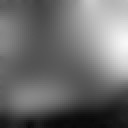

In [45]:
solution = Gray.(max.(min.(reshape(evaluate_at_points(ph, prblm.fe.dh, u),(64,64)),1.0),0.0))

In [46]:
using Printf
fmt(x) = @sprintf("%.3e", x) 
fname = "Tikhonov/$(fmt(ρ_reg))_$(fmt(ρ_obj))_$(fmt(σf))_$(fmt(σg)).png"
save(fname, solution)